# Part 1: Data Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snsS
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 1. Load the dataset and review its structure.
fd =  pd.read_csv('Employee.csv')
fd.head()


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [4]:
# 2. Identify the categorical and numerical features.
fd.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [9]:
# 3. Check for missing values
fd.isnull().sum()

# Handle missing values
fd.dropna(inplace=True)

fd.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [ ]:
# 4. Compute summary statistics for numerical features (Age, PaymentTier, ExperienceInCurrentDomain)

numerical_cols = ['Age', 'PaymentTier', 'ExperienceInCurrentDomain']

fd[numerical_cols].describe()


,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000



Education Distribution:
Education
Bachelors    3601
Masters       873
PHD           179
Name: count, dtype: int64
Education
Bachelors    77.39%
Masters      18.76%
PHD           3.85%
Name: proportion, dtype: object

City Distribution:
City
Bangalore    2228
Pune         1268
New Delhi    1157
Name: count, dtype: int64
City
Bangalore    47.88%
Pune         27.25%
New Delhi    24.87%
Name: proportion, dtype: object

Gender Distribution:
Gender
Male      2778
Female    1875
Name: count, dtype: int64
Gender
Male      59.7%
Female    40.3%
Name: proportion, dtype: object

EverBenched Distribution:
EverBenched
No     4175
Yes     478
Name: count, dtype: int64
EverBenched
No     89.73%
Yes    10.27%
Name: proportion, dtype: object


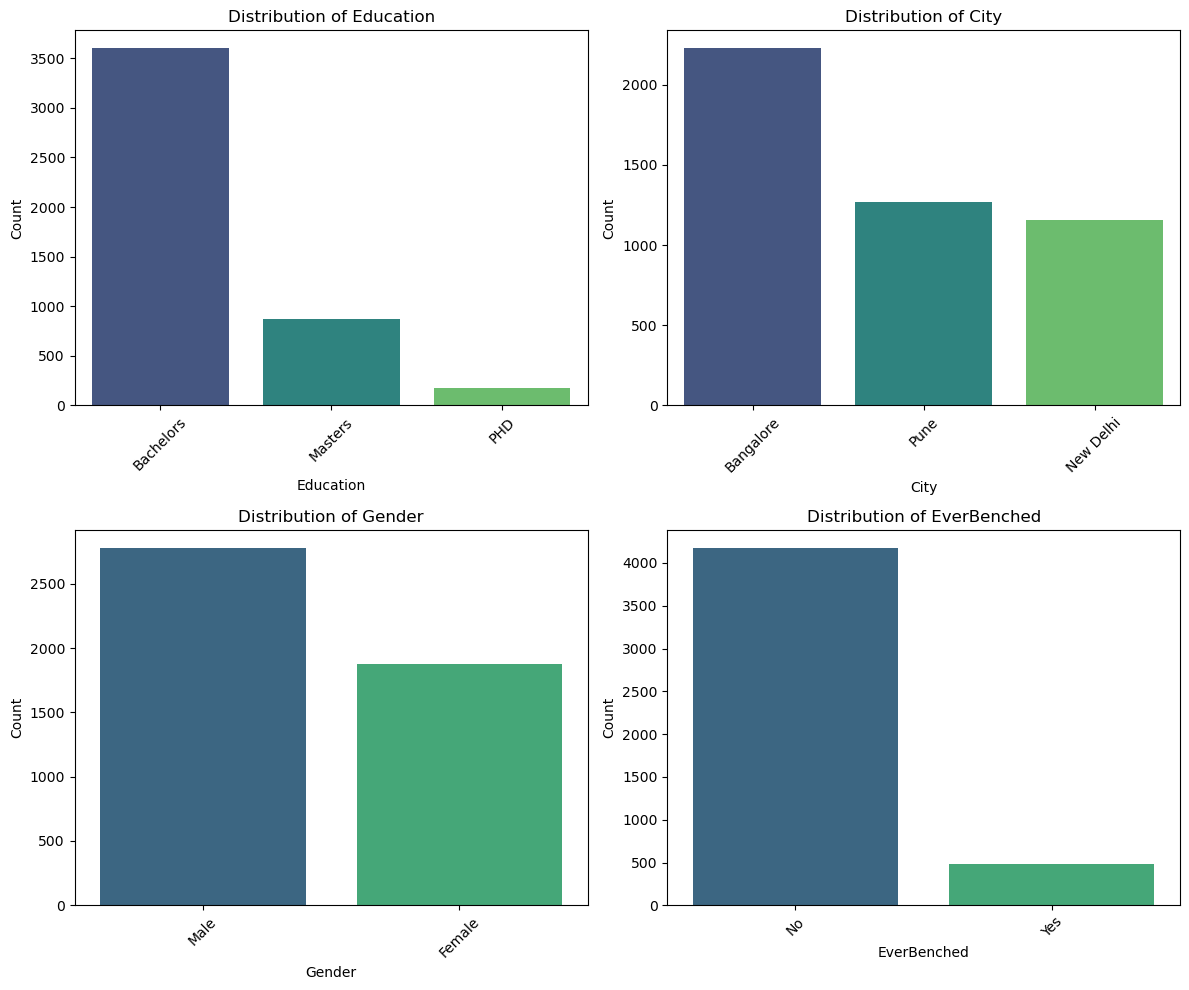

In [13]:
# 5. Analyze the distribution of categorical features (Education, City, Gender, EverBenched)

categorical_cols = ['Education', 'City', 'Gender', 'EverBenched']

for col in categorical_cols:
    print(f"\n{col} Distribution:")
    print(fd[col].value_counts())
    print(fd[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    snsS.countplot(data=fd, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


LeaveOrNot Distribution:
LeaveOrNot
0    3053
1    1600
Name: count, dtype: int64
LeaveOrNot
0    65.61%
1    34.39%
Name: proportion, dtype: object


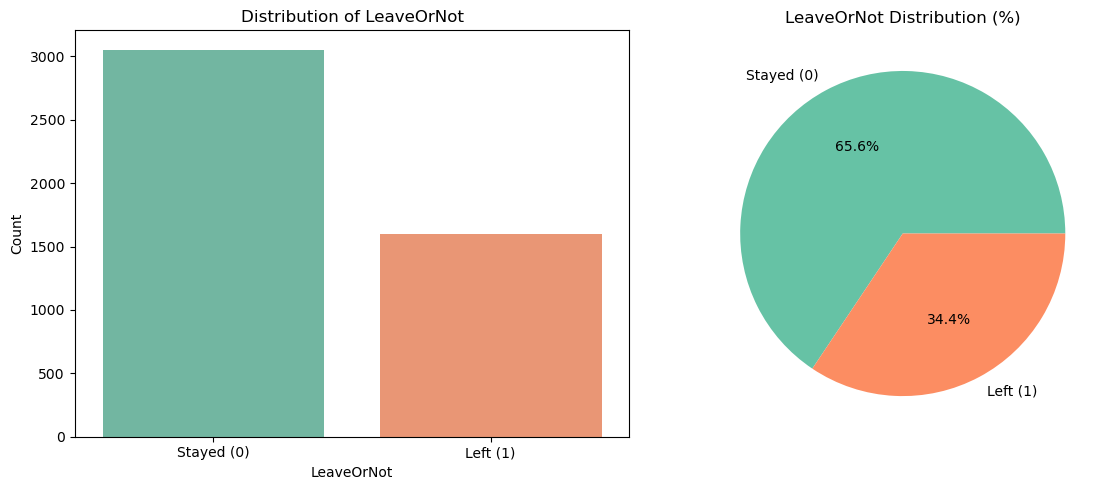

In [16]:
# 6. Plot or visualize the distribution of the target variable LeaveOrNot.

print("LeaveOrNot Distribution:")
print(fd['LeaveOrNot'].value_counts())
print(fd['LeaveOrNot'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

labels = ['Stayed (0)', 'Left (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

snsS.countplot(data=fd, x='LeaveOrNot', ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of LeaveOrNot')
axes[0].set_xlabel('LeaveOrNot')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(labels)

fd['LeaveOrNot'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', labels=labels, colors=snsS.color_palette('Set2'))
axes[1].set_title('LeaveOrNot Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


# Part 2: Data Preprocessing

In [ ]:
# 1. Encode categorical features (Education, City, Gender, EverBenched) appropriately.

df_encoded = fd.copy()

# Education - Ordinal encoding (Bachelors < Masters < PHD)
education_order = {'Bachelors': 0, 'Masters': 1, 'PHD': 2}
df_encoded['Education'] = df_encoded['Education'].map(education_order)

# Gender - Binary encoding
df_encoded['Gender'] = df_encoded['Gender'].map({'Male': 0, 'Female': 1})

# EverBenched - Binary encoding
df_encoded['EverBenched'] = df_encoded['EverBenched'].map({'No': 0, 'Yes': 1})

# City - One-Hot encoding (nominal feature, no natural order)
city_dummies = pd.get_dummies(df_encoded['City'], drop_first=True)
df_encoded = pd.concat([df_encoded.drop('City', axis=1), city_dummies], axis=1)

print("Encoded Dataset:")
df_encoded.head()
